# 04 — Model Training & Comparison
**Home Credit Default Risk — Capstone Step 3**

Objective: train 3 model types, compare performance using financial metrics, and select the best model.

**Target: AUROC ≥ 0.72 on the held-out test set.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, f1_score)
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier
import os

sns.set_style('whitegrid')
DATA_DIR = '../data/'

## 1. Load Data and Split

In [2]:
df = pd.read_csv(DATA_DIR + 'final_train.csv')
print(df.shape)

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Sauvegarde explicite du test set pour la démo/documentation
test_set = X_test.copy()
test_set['TARGET'] = y_test
test_set.to_csv('../data/test_set.csv', index=False)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train default rate:", y_train.mean().round(4), "Test default rate:", y_test.mean().round(4))

(307511, 230)
Train: (246008, 228) Test: (61503, 228)
Train default rate: 0.0807 Test default rate: 0.0807


## 2. Train Model 1: Logistic Regression (Baseline)

L2-regularized (Ridge, the sklearn default) — per Step 2's VIF findings, this handles the moderate multicollinearity in the engineered ratio features gracefully.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


## 3. Train Model 2: Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 4. Train Model 3: Gradient Boosting

**Note:** Using `HistGradientBoostingClassifier` (scikit-learn's histogram-based implementation) rather than the standard `GradientBoostingClassifier`, for computational efficiency on this 307K-row dataset : `HistGradientBoostingClassifier` is significantly faster while remaining conceptually the same algorithm (and is closely related to LightGBM).

In [15]:
gb = HistGradientBoostingClassifier(max_iter=200, max_depth=4, learning_rate=0.05,
                                      class_weight='balanced', random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting (Hist) trained.")

Gradient Boosting (Hist) trained.


## 5. Financial Metrics for All Models

AUROC, Gini (2×AUROC−1), KS statistic, AUPRC, F1 at the optimal threshold — per the brief, accuracy is not used since it's misleading on this imbalanced dataset.

In [16]:
def ks_statistic(y_true, y_proba):
    """Kolmogorov-Smirnov statistic: max separation between the cumulative
    distributions of the positive and negative class."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(np.abs(tpr - fpr))

def best_f1_threshold(y_true, y_proba):
    """Find the threshold that maximizes F1, rather than defaulting to 0.5."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])  # last point has no corresponding threshold
    return thresholds[best_idx], f1s[best_idx]

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gb,
}

results = []
proba_dict = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        proba = model.predict_proba(X_test)[:, 1]
    proba_dict[name] = proba

    auroc = roc_auc_score(y_test, proba)
    gini = 2 * auroc - 1
    ks = ks_statistic(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    best_thresh, best_f1 = best_f1_threshold(y_test, proba)

    results.append({
        'Model': name,
        'AUROC': auroc,
        'Gini': gini,
        'KS': ks,
        'AUPRC': auprc,
        'F1 (optimal threshold)': best_f1,
        'Optimal threshold': best_thresh,
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)


,AUROC,Gini,KS,AUPRC,F1 (optimal threshold),Optimal threshold
Model,,,,,,
Logistic Regression,0.7543,0.5087,0.3795,0.2411,0.3093,0.6755
Random Forest,0.7456,0.4912,0.3694,0.2257,0.2942,0.6002
Gradient Boosting,0.7637,0.5274,0.3910,0.2552,0.3188,0.6740


**Interpretation:**

Gradient Boosting wins on both AUROC (0.7637) and AUPRC (0.2552), as well as every other metric (Gini 0.5274, KS 0.3910, F1 0.3188).

Logistic Regression comes second on AUROC (0.7543), narrowly beating Random Forest (0.7456), while on AUPRC Logistic Regression (0.2411) also edges out Random Forest (0.2257).

The gap between Gradient Boosting and Logistic Regression is modest (~0.009 AUROC), worth noting in the final documentation as a trade-off between marginal performance gain and interpretability, even though Gradient Boosting is selected as the best model going forward.

The relatively narrow gap between Logistic Regression and Gradient Boosting suggests the engineered features (ratios, EXT_SOURCE combinations) capture much of the predictive signal in an already fairly linear/monotone form.

**Note:** Gradient Boosting here uses `HistGradientBoostingClassifier` rather than the standard `GradientBoostingClassifier`, for computational efficiency on this 307K-row dataset — conceptually the same algorithm, closely related to LightGBM.

## 6. ROC and Precision-Recall Curves

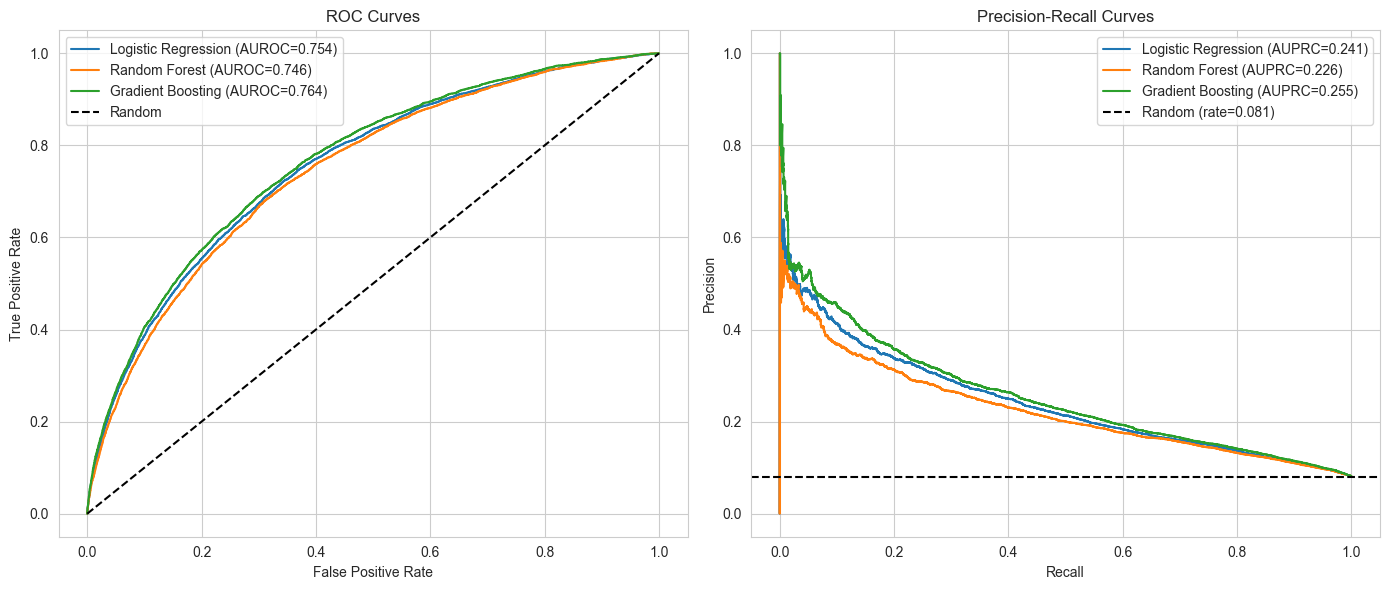

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, proba in proba_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUROC={roc_auc_score(y_test, proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

for name, proba in proba_dict.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f'{name} (AUPRC={average_precision_score(y_test, proba):.3f})')

baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, color='k', linestyle='--', label=f'Random (rate={baseline_rate:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

plt.tight_layout()
os.makedirs('../figs', exist_ok=True)
plt.savefig('../figs/roc_pr_curves.png', dpi=300)
plt.show()

**Interpretation:**

The ROC curves confirm Gradient Boosting (green) consistently outperforms both other models across nearly the entire range of thresholds, not just on average, its curve sits visibly above Logistic Regression and Random Forest throughout. 

The Precision-Recall curves tell a similar story, though all three curves show the expected steep decline as recall increases, consistent with the ~8% base default rate. All three models clear the "Random" baseline by a wide margin, especially at low recall, where precision-focused decisions (only flagging the highest-risk applicants) would work best.

## 7. Cross-Validation (StratifiedKFold, 5 folds)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
    cv_results[name] = scores
    print(f"{name}: mean AUROC = {scores.mean():.4f}, std = {scores.std():.4f}")

Logistic Regression: mean AUROC = 0.7508, std = 0.0028
Random Forest: mean AUROC = 0.7409, std = 0.0024
Gradient Boosting: mean AUROC = 0.7601, std = 0.0010


**Interpretation:**

All three models show low standard deviation across folds (0.0010–0.0028), confirming stable, reliable performance, none of the models' scores depend heavily on which specific rows land in which fold. 

Gradient Boosting not only achieves the highest mean AUROC (0.7601) but also the lowest std (0.0010), making it both the best-performing and the most stable model of the three, reinforcing its selection as the best model for hyperparameter tuning in the next step.

In [ ]:
param_dist = {
    'max_iter': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, None],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_regularization': [0, 0.1, 1.0],
}

gb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=1,
    verbose=1,
)
gb_search.fit(X_train, y_train)

print("Best params:", gb_search.best_params_)
print("Best CV AUROC:", gb_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'max_iter': 200, 'max_depth': 6, 'learning_rate': 0.05, 'l2_regularization': 1.0}
Best CV AUROC: 0.7628176461803288


In [19]:
tuned_model = gb_search.best_estimator_
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]
tuned_auroc = roc_auc_score(y_test, tuned_proba)
print(f"Tuned model test AUROC: {tuned_auroc:.4f}")

Tuned model test AUROC: 0.7678


**Interpretation:**

Hyperparameter tuning improved the model from 0.7637 (default HistGradientBoostingClassifier) to 0.7678 AUROC on the held-out test set, consistent with the model already being reasonably well-specified before tuning. The best parameters found were: 
- max_iter=200
- max_depth=6
- learning_rate=0.05
- l2_regularization=1.0.  

This final AUROC of 0.7678 represents the model saved to models/best_model.pkl.

## 9. Save Best Model

In [20]:
os.makedirs('../models', exist_ok=True)
joblib.dump(tuned_model, '../models/best_model.pkl')
print("Saved: ../models/best_model.pkl")

Saved: ../models/best_model.pkl
